# 01 · The car as data

Deep dive on outlap's core contract: **a car is a directory of files, never code**. This
notebook covers the input quartet, what validation feels like when you get something wrong,
the loaded-model report, and the *what-if override* API that powers every interactive panel
in this series.

*Prerequisite: none — start here after the [tour](00_tour_of_outlap.ipynb).*

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# CI-speed solver pin for this notebook's parameter sweeps: every distinct override/conditions
# combination is a new resolved car and regenerates its g-g-g-v envelope (the cold assembly step),
# so the sweeps here run the point-mass tier on a coarse envelope. The production default
# (tier t1, 40x25x7 grid) is what `solve_lap_dataset(...)` gives with no arguments.
FAST = dict(tier="t0", sim={"envelope": {"v_points": 8, "ax_points": 7, "g_normal_points": 2}})

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

from outlap.core import Track, solve_lap_dataset, vehicle_report

VEH = str(ROOT / "data" / "vehicles" / "f1_2026")
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))


## The input quartet

Everything a simulation needs splits into four files with strictly separated concerns —
car identity never mixes with environment or numerics:

| file | owns | example fields |
|---|---|---|
| `vehicle.yaml` | the car | chassis, aero, suspension, tyres, drivetrain topology |
| `track.yaml` (+ CSV) | the road | centerline, widths, elevation, banking |
| `conditions.yaml` | the session | air temperature/pressure, wind, track temperature |
| `sim.yaml` | the numerics | steps, tolerances, solver settings |

The same `vehicle.yaml` feeds every solver tier — there is no per-tier re-parameterisation,
ever. Here's the reference car's skeleton (top-level keys):

In [2]:
import yaml

spec = yaml.safe_load((Path(VEH) / "vehicle.yaml").read_text())
for key, val in spec.items():
    kind = type(val).__name__
    inner = f" ({', '.join(list(val)[:6])}…)" if isinstance(val, dict) else ""
    print(f"  {key:12s} {kind}{inner}")

  schema       str
  name         str
  chassis      dict (mass_kg, cg, inertia, wheelbase_m, track_m…)
  aero         dict (map, axes, constant…)
  suspension   dict (model, front, rear…)
  tires        dict (front, rear…)
  drivetrain   dict (units…)
  ers          dict (mgu_k, es, deployment, override_mode, recovery…)
  battery      dict (model, params…)
  brakes       dict (balance_bar, disc, regen_blend…)


## Validation is a product surface

Config errors come back as real diagnostics — plain language with did-you-mean suggestions,
never stack traces (the Rust CLI surface adds full source-code spans on top). Watch what
happens when we misspell a required chassis field:

In [3]:
import shutil
import tempfile

_tmpdir = tempfile.TemporaryDirectory()  # held so it is cleaned up with the kernel
tmp = Path(_tmpdir.name)
broken = tmp / "veh"
shutil.copytree(VEH, broken)
text = (broken / "vehicle.yaml").read_text().replace("mass_kg:", "mas_kg:", 1)
(broken / "vehicle.yaml").write_text(text)

try:
    solve_lap_dataset(str(broken), track)
except ValueError as e:
    print("\n".join(str(e).splitlines()[:10]))

unknown field `mas_kg`
help: did you mean `mass_kg`?


## Nothing is silent

Any value the loader had to **estimate** (from a documented heuristic), inherit from a preset,
or degrade is listed in the loaded-model report, and the whole resolved car is hashed so every
result is traceable to the exact spec that produced it.

In [4]:
rep = vehicle_report(VEH)
print(f"{rep['name']} · hash {str(rep['resolved_hash'])[:16]}…")
for pointer, detail in rep["estimated"]:
    print(f"  estimated  {pointer:40s} {detail[:60]}")

Reference F1 2026 hybrid · hash 9b69eda3e26b732f…
  estimated  /suspension/front/anti_squat             assumed 0 (no anti-squat geometry)
  estimated  /suspension/front/camber_map             no camber map — assumed zero camber change with travel
  estimated  /suspension/front/toe_map                no toe map — assumed zero toe change with travel
  estimated  /suspension/rear/anti_dive               assumed 0 (no anti-dive geometry)
  estimated  /suspension/rear/camber_map              no camber map — assumed zero camber change with travel
  estimated  /suspension/rear/toe_map                 no toe map — assumed zero toe change with travel
  estimated  /driver/preview_time_s                   literature default 0.6 — MacAdam preview time, s (tuned on l
  estimated  /driver/preview_gain                     literature default 0.2 — preview steer gain, rad/m (tuned on
  estimated  /driver/heading_gain                     literature default 1 — heading-error steer gain, rad/rad (tu
  es

## What-if overrides — editing the car without editing files

`overrides` patches **dotted paths** onto the vehicle *through the real pipeline* (Decision
#35): the patched value is schema-validated after the merge, a typo'd path fails with the
loader's own diagnostics, and the resolved hash changes. `conditions` does the same for the
session. This is the mechanism every slider in these notebooks drives.

In [5]:
# Baselines come from the spec itself, so the relative labels stay honest.
aero = spec["aero"]["constant"]
m0, czf0, czr0, cx0 = (spec["chassis"]["mass_kg"], aero["cz_front_a_m2"],
                       aero["cz_rear_a_m2"], aero["cx_a_m2"])
experiments = {
    "baseline": {},
    "+100 kg": {"overrides": {"chassis.mass_kg": m0 + 100.0}},
    "-30 % rear wing": {"overrides": {"aero.constant.cz_rear_a_m2": czr0 * 0.7}},
    "+10 % drag": {"overrides": {"aero.constant.cx_a_m2": cx0 * 1.1}},
    "hot day (40 °C)": {"conditions": {"air": {"temperature_c": 40.0}}},
}
for label, kw in experiments.items():
    lap = solve_lap_dataset(VEH, track, **kw, **FAST)
    print(f"  {label:18s} {lap.attrs['lap_time_s']:8.3f} s")

# A typo'd path is an error, not a silent no-op:
try:
    solve_lap_dataset(VEH, track, overrides={"chassis.mas_kg": 900.0})
except ValueError as e:
    print("\ntypo'd override →", str(e).splitlines()[0][:90], "…")

  baseline            115.294 s
  +100 kg             118.050 s


  -30 % rear wing     115.294 s
  +10 % drag          115.176 s


  hot day (40 °C)     116.113 s

typo'd override → unknown field `mas_kg` …


### Sensitivity at a glance

Which knob matters most? Perturb each one by a fixed relative amount and chart the lap-time
delta (the static twin of the sliders below):

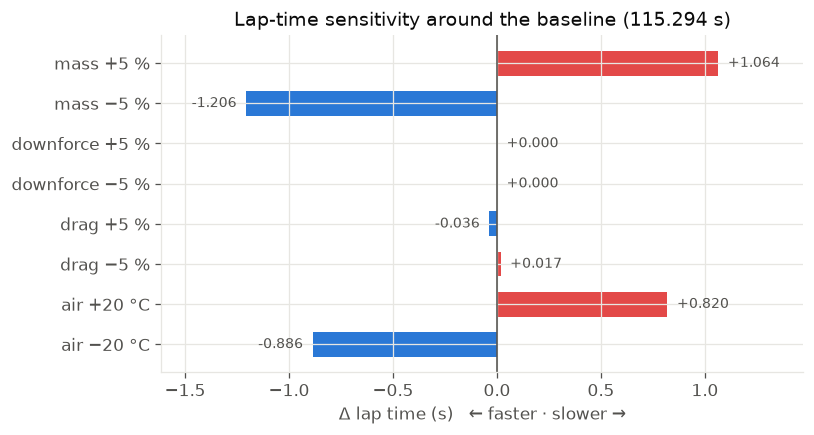

In [6]:
base_t = solve_lap_dataset(VEH, track, **FAST).attrs["lap_time_s"]
levers = [
    ("mass +5 %", {"overrides": {"chassis.mass_kg": m0 * 1.05}}),
    ("mass −5 %", {"overrides": {"chassis.mass_kg": m0 * 0.95}}),
    ("downforce +5 %", {"overrides": {"aero.constant.cz_front_a_m2": czf0 * 1.05,
                                      "aero.constant.cz_rear_a_m2": czr0 * 1.05}}),
    ("downforce −5 %", {"overrides": {"aero.constant.cz_front_a_m2": czf0 * 0.95,
                                      "aero.constant.cz_rear_a_m2": czr0 * 0.95}}),
    ("drag +5 %", {"overrides": {"aero.constant.cx_a_m2": cx0 * 1.05}}),
    ("drag −5 %", {"overrides": {"aero.constant.cx_a_m2": cx0 * 0.95}}),
    ("air +20 °C", {"conditions": {"air": {"temperature_c": 40.0}}}),
    ("air −20 °C", {"conditions": {"air": {"temperature_c": 0.0}}}),
]
deltas = [solve_lap_dataset(VEH, track, **kw, **FAST).attrs["lap_time_s"] - base_t for _, kw in levers]

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ypos = np.arange(len(levers))[::-1]
colors = [RED if d > 0 else BLUE for d in deltas]
ax.barh(ypos, deltas, color=colors, height=0.62)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ypos, [n for n, _ in levers])
ax.set_xlabel("Δ lap time (s)   ← faster · slower →")
ax.set_title(f"Lap-time sensitivity around the baseline ({base_t:.3f} s)")
ax.margins(x=0.18)
for yp, d in zip(ypos, deltas):
    ax.annotate(f"{d:+.3f}", (d, yp), xytext=(6 if d >= 0 else -6, 0),
                textcoords="offset points", va="center",
                ha="left" if d >= 0 else "right", color=INK2, fontsize=9)
plt.tight_layout()
plt.show()

> **▶ Interactive.** The next cell is live only in a running Jupyter (`uv sync --group notebooks`,
> then `uv run --with jupyterlab jupyter lab`). On GitHub you're seeing its static twin above.

interactive(children=(FloatSlider(value=768.0, description='mass kg', max=1000.0, min=650.0, step=10.0), Float…

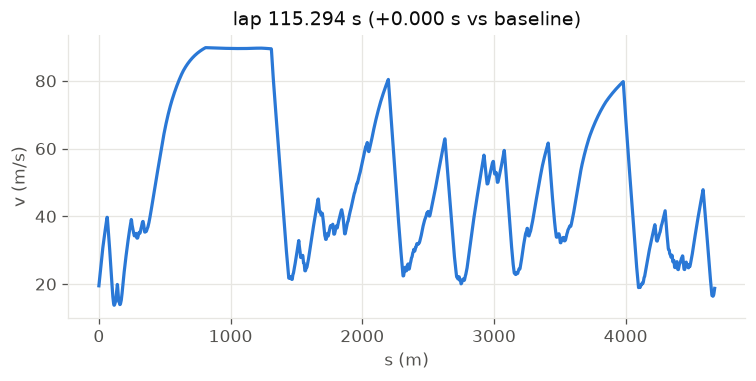

In [7]:
if HAVE_WIDGETS:

    @widgets.interact(
        mass=widgets.FloatSlider(min=650, max=1000, step=10, value=768, description="mass kg"),
        wing=widgets.FloatSlider(min=0.5, max=1.5, step=0.05, value=1.0, description="wing ×"),
        temp=widgets.FloatSlider(min=-5, max=45, step=5, value=20, description="air °C"),
    )
    def what_if(mass: float, wing: float, temp: float) -> None:
        lap = solve_lap_dataset(
            VEH, track,
            **FAST,
            overrides={"chassis.mass_kg": mass,
                       "aero.constant.cz_front_a_m2": czf0 * wing,
                       "aero.constant.cz_rear_a_m2": czr0 * wing},
            conditions={"air": {"temperature_c": temp}},
        )
        fig, ax = plt.subplots(figsize=(7.6, 3.2))
        ax.plot(lap.s, lap.v, color=BLUE)
        ax.set_xlabel("s (m)")
        ax.set_ylabel("v (m/s)")
        ax.set_title(f"lap {lap.attrs['lap_time_s']:.3f} s "
                     f"({lap.attrs['lap_time_s'] - base_t:+.3f} s vs baseline)")
        plt.show()

    what_if(float(m0), 1.0, 20.0)  # direct call: a real error here must fail CI

**Next:** [02 · the 3D track](02_track.ipynb) — where the road data comes from and what the
ribbon can answer.